In [1]:
import os
import pickle
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFECV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

/Users/thiagosantana/steel-demand-forecast/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
datetime_str = datetime.strftime(datetime.now(), '%Y-%m-%d_%H-%M-%S')
os.makedirs('./secoes/', exist_ok=True)
os.makedirs(f'./secoes/resultados_{datetime_str}', exist_ok=True)
path_secao_atual = f'./secoes/resultados_{datetime_str}'
print(f'Resultados serão salvos em: {path_secao_atual}')

Resultados serão salvos em: ./secoes/resultados_2026-06-30_16-38-48


In [3]:
os.makedirs('./Modelos', exist_ok=True)

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df_tabela_mestre = pd.read_excel('../dados/gold/tabela_mestre.xlsx', engine='openpyxl')

In [6]:
df_tabela_mestre.head()

,Date,Consumo Aparente,AUTOVEÍCULOS TOTAL_Produção,AUTOMÓVEIS_Produção,COMERCIAIS LEVES_Produção,CAMINHÕES_Produção,ÔNIBUS_Produção,producao_total,IPCA,PIB_mensal,operacoes_credito_industria_construcao,operacoes_credito_industria_infraestrutura,operacoes_credito_industria_metalurgia_siderurgia,Outra,km,kva,kw,m2,m3,VALUE (R$),taxa_selic_aa,24 METALURGIA,"25 FABRICAÇÃO DE PRODUTOS DE METAL, EXCETO MÁQUINAS E EQUIPAMENTOS","27 FABRICAÇÃO DE MÁQUINAS, APARELHOS E MATERIAIS ELÉTRICOS",28 FABRICAÇÃO DE MÁQUINAS E EQUIPAMENTOS,"29 FABRICAÇÃO DE VEÍCULOS AUTOMOTORES, REBOQUES E CARROCERIAS","30 FABRICAÇÃO DE OUTROS EQUIPAMENTOS DE TRANSPORTE, EXCETO VEÍCULOS AUTOMOTORES",3.24 Metalurgia,3.28 Fabricação de máquinas e equipamentos,"3.29 Fabricação de veículos automotores, reboques e carrocerias","3.30 Fabricação de outros equipamentos de transporte, exceto veículos automotores","Nível da ocupação, na semana de referência, das pessoas de 14 anos ou mais de idade",custo_projeto_m2
0,2013-01-01,905.896,291884,237700,38430,12622,3132,583768,0.86,408895.0,93691,23988,47137,226535.31,1318.93,0.0,0.00,6256607.14,57915.94,1.440984,7.442417,71.51497,77.06881,76.65715,81.08439,77.66284,62.19166,1598.927,660.4378,967.89891,1304.52774,58.5,1822703.31
1,2013-02-01,874.438,242072,191832,33564,13664,3012,484144,0.60,398087.4,94316,24318,47802,2375468.83,35356.44,300.0,0.00,3585060.38,202427.96,1.268150,6.041083,71.51497,77.06881,76.65715,81.08439,77.66284,62.19166,1598.927,660.4378,967.89891,1304.52774,58.5,1822703.31
2,2013-03-01,1018.972,329103,265001,43782,16533,3787,658206,0.47,434631.2,96662,24734,48433,37550.53,151.27,0.0,143845.00,3590771.35,296.10,1.278884,6.803356,71.51497,77.06881,76.65715,81.08439,77.66284,62.19166,1598.927,660.4378,967.89891,1304.52774,58.5,1822703.31
3,2013-04-01,1035.119,352328,278924,51538,18034,3832,704656,0.55,446508.1,97451,24901,48442,86607783.93,18317.29,0.0,56.24,4193890.04,21194.45,1.467863,7.570649,71.51497,77.06881,76.65715,81.08439,77.66284,62.19166,1598.927,660.4378,967.89891,1304.52774,58.5,1822703.31
4,2013-05-01,1053.642,344556,275799,48491,16378,3888,689112,0.37,441321.9,99717,25191,48803,616190.93,1561.29,0.0,117.06,4526387.72,48913.61,1.378052,7.442417,71.51497,77.06881,76.65715,81.08439,77.66284,62.19166,1598.927,660.4378,967.89891,1304.52774,58.5,1822703.31


In [7]:
df_tabela_mestre.shape

(161, 33)

## 1. Análise Exploratória (EDA)

Colunas com valores nulos (%):
Series([], dtype: float64)


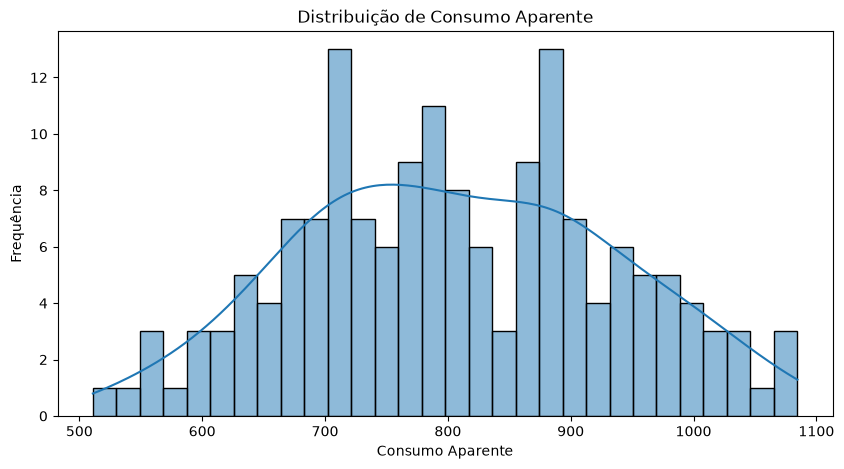

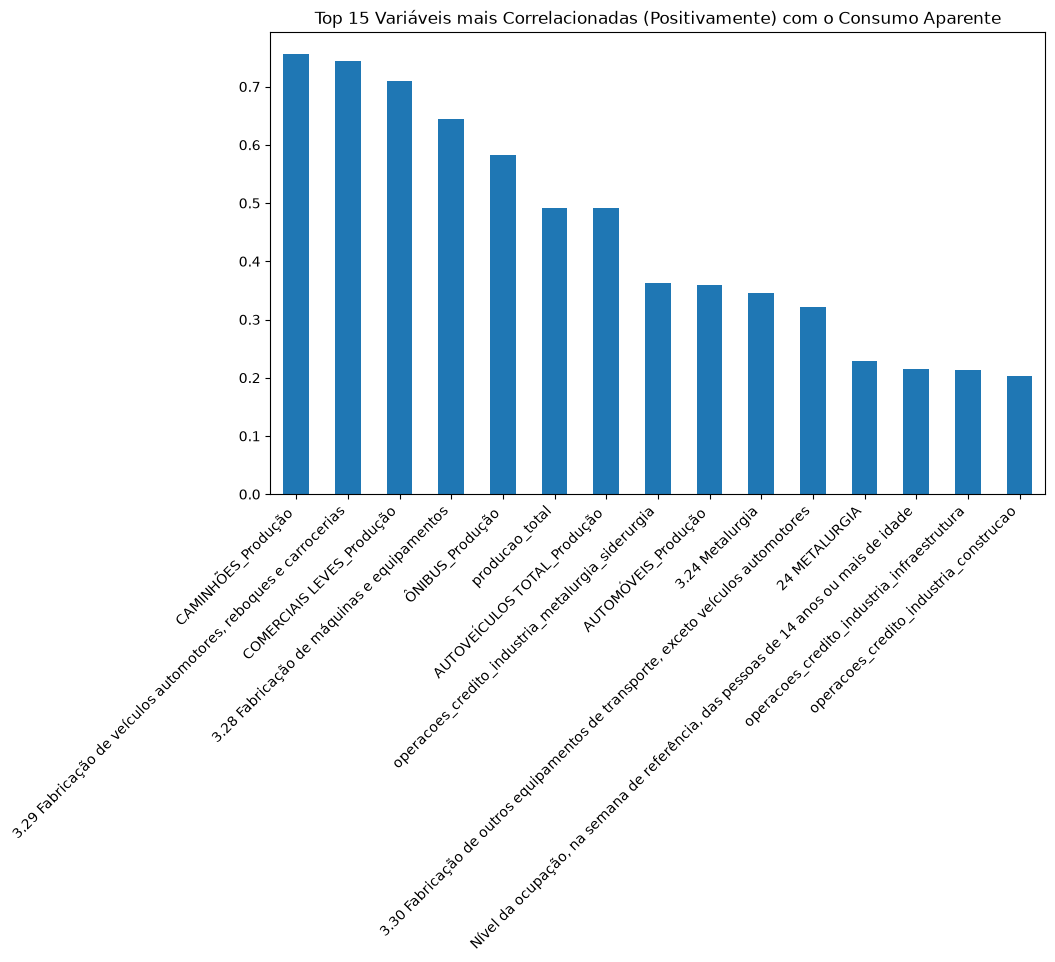

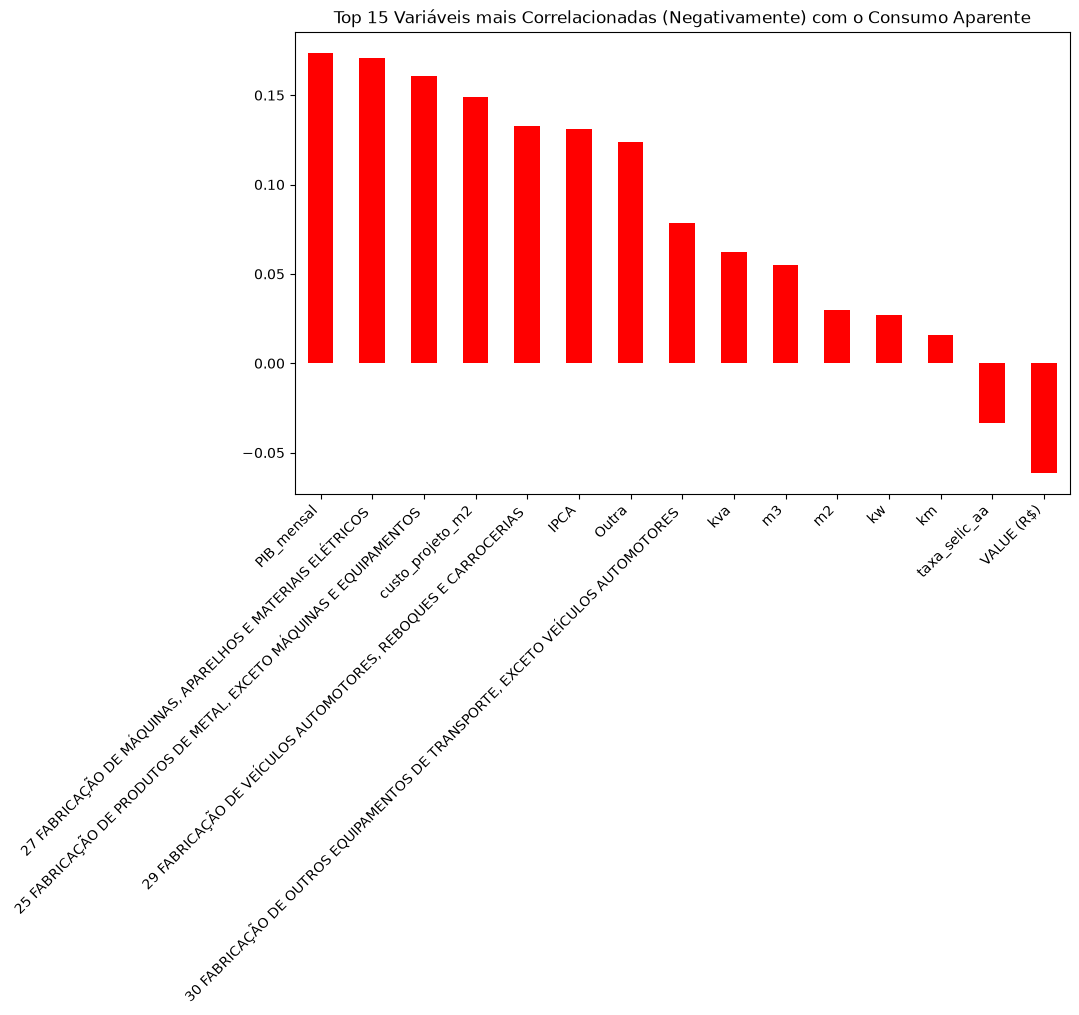

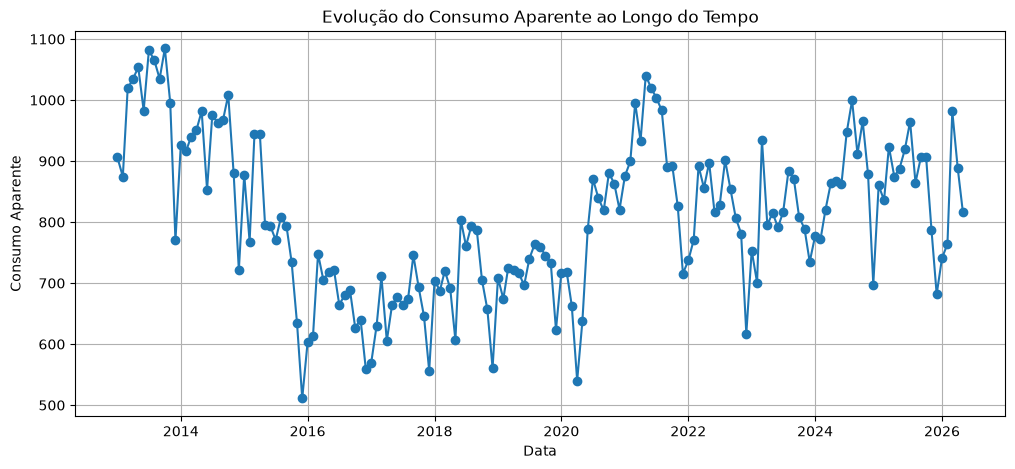

In [8]:
# Remover colunas com mais de 50% de nulos caso existam, ou apenas visualizar
missing = df_tabela_mestre.isnull().mean() * 100
print("Colunas com valores nulos (%):")
print(missing[missing > 0].sort_values(ascending=False))

# Distribuição da Variável Target
plt.figure(figsize=(10, 5))
sns.histplot(df_tabela_mestre['Consumo Aparente'], kde=True, bins=30)
plt.title('Distribuição de Consumo Aparente')
plt.xlabel('Consumo Aparente')
plt.ylabel('Frequência')
plt.show()

# Correlação com a variável Target (top 15)
numeric_df = df_tabela_mestre.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['Consumo Aparente'].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
correlations.drop('Consumo Aparente').head(15).plot(kind='bar')
plt.title('Top 15 Variáveis mais Correlacionadas (Positivamente) com o Consumo Aparente')
plt.xticks(rotation=45, ha='right')
plt.show()

# Correlações Negativas (top 15)
plt.figure(figsize=(10, 6))
correlations.tail(15).plot(kind='bar', color='red')
plt.title('Top 15 Variáveis mais Correlacionadas (Negativamente) com o Consumo Aparente')
plt.xticks(rotation=45, ha='right')
plt.show()

# Evolução do Consumo ao longo do tempo (se aplicável)
if 'Date' in df_tabela_mestre.columns:
    df_temp = df_tabela_mestre.copy()
    df_temp['Date'] = pd.to_datetime(df_temp['Date'])
    df_temp.sort_values('Date', inplace=True)
    
    plt.figure(figsize=(12, 5))
    plt.plot(df_temp['Date'], df_temp['Consumo Aparente'], marker='o', linestyle='-')
    plt.title('Evolução do Consumo Aparente ao Longo do Tempo')
    plt.xlabel('Data')
    plt.ylabel('Consumo Aparente')
    plt.grid(True)
    plt.show()


## Remoção de Variáveis Muito Correlacionadas (Multicolinearidade)

In [9]:
# Removeremos a variável target da verificação para garantir que ela não seja removida
numeric_cols = df_tabela_mestre.select_dtypes(include=[np.number]).columns.tolist()
if 'Consumo Aparente' in numeric_cols:
    numeric_cols.remove('Consumo Aparente')

# Calcular matriz de correlação absoluta
corr_matrix = df_tabela_mestre[numeric_cols].corr().abs()

# Obter triângulo superior da matriz de correlação
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identificar variáveis com correlação superior a 0.90
threshold = 0.90
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print(f"Variáveis muito correlacionadas a serem removidas ({len(to_drop)}):")
for col in to_drop:
    print(f" - {col}")

# Remover as colunas identificadas
df_tabela_mestre = df_tabela_mestre.drop(columns=to_drop)

print("\nShape do dataset após remoção das variáveis correlacionadas:", df_tabela_mestre.shape)

Variáveis muito correlacionadas a serem removidas (10):
 - AUTOMÓVEIS_Produção
 - producao_total
 - operacoes_credito_industria_infraestrutura
 - 24 METALURGIA
 - 25 FABRICAÇÃO DE PRODUTOS DE METAL, EXCETO MÁQUINAS E EQUIPAMENTOS
 - 27 FABRICAÇÃO DE MÁQUINAS, APARELHOS E MATERIAIS ELÉTRICOS
 - 28 FABRICAÇÃO DE MÁQUINAS E EQUIPAMENTOS
 - 29 FABRICAÇÃO DE VEÍCULOS AUTOMOTORES, REBOQUES E CARROCERIAS
 - 30 FABRICAÇÃO DE OUTROS EQUIPAMENTOS DE TRANSPORTE, EXCETO VEÍCULOS AUTOMOTORES
 - custo_projeto_m2

Shape do dataset após remoção das variáveis correlacionadas: (161, 23)


## Feature Engineering: Lags, Médias Móveis e Codificação Cíclica do Mês

In [10]:
df_tabela_mestre = df_tabela_mestre.sort_values('Date').reset_index(drop=True)

# Lags do target — shift garante que não há look-ahead
for lag in [1, 2, 3]:
    df_tabela_mestre[f'consumo_lag_{lag}'] = df_tabela_mestre['Consumo Aparente'].shift(lag)

# Médias móveis — shift(1) antes do rolling evita usar o valor corrente
df_tabela_mestre['consumo_ma3']  = df_tabela_mestre['Consumo Aparente'].shift(1).rolling(3).mean()
df_tabela_mestre['consumo_ma6']  = df_tabela_mestre['Consumo Aparente'].shift(1).rolling(6).mean()
df_tabela_mestre['consumo_ma12'] = df_tabela_mestre['Consumo Aparente'].shift(1).rolling(12).mean()

# Codificação cíclica do mês (sin/cos em vez de inteiro 1-12)
# Inteiro bruto implica que dezembro (12) > janeiro (1), quebrando a ciclicidade
df_tabela_mestre['mes_sin'] = np.sin(2 * np.pi * df_tabela_mestre['Date'].dt.month / 12)
df_tabela_mestre['mes_cos'] = np.cos(2 * np.pi * df_tabela_mestre['Date'].dt.month / 12)

# Trend linear substitui 'ano' bruto, que extrapolaria mal fora do range de treino
df_tabela_mestre['trend'] = range(len(df_tabela_mestre))

# Remover linhas com NaN gerados pelos lags (primeiros 12 meses)
df_tabela_mestre = df_tabela_mestre.dropna().reset_index(drop=True)
print(f"Shape após feature engineering: {df_tabela_mestre.shape}")
print(f"Período: {df_tabela_mestre['Date'].min().date()} → {df_tabela_mestre['Date'].max().date()}")

Shape após feature engineering: (149, 32)
Período: 2014-01-01 → 2026-05-01


## Seleção de Features — Etapa 1: Filtro de Correlação

In [11]:
df_tabela_mestre.head()

,Date,Consumo Aparente,AUTOVEÍCULOS TOTAL_Produção,COMERCIAIS LEVES_Produção,CAMINHÕES_Produção,ÔNIBUS_Produção,IPCA,PIB_mensal,operacoes_credito_industria_construcao,operacoes_credito_industria_metalurgia_siderurgia,Outra,km,kva,kw,m2,m3,VALUE (R$),taxa_selic_aa,3.24 Metalurgia,3.28 Fabricação de máquinas e equipamentos,"3.29 Fabricação de veículos automotores, reboques e carrocerias","3.30 Fabricação de outros equipamentos de transporte, exceto veículos automotores","Nível da ocupação, na semana de referência, das pessoas de 14 anos ou mais de idade",consumo_lag_1,consumo_lag_2,consumo_lag_3,consumo_ma3,consumo_ma6,consumo_ma12,mes_sin,mes_cos,trend
0,2014-01-01,927.046,237390,30088,13776,2431,0.55,453274.2,107896,48880,5.273980e+05,13224.64,150.0,0.00,7793517.45,67046.35,1.690171,10.690623,1598.927,660.4378,967.89891,1304.52774,58.2,769.865,995.462,1084.536,949.954333,1005.247667,991.862417,0.500000,8.660254e-01,12
1,2014-02-01,916.842,281627,39125,15174,3750,0.69,455505.4,108950,49258,1.882174e+06,12370.35,0.0,60000.00,4172578.38,14043.68,1.702207,9.902948,1598.927,660.4378,967.89891,1304.52774,58.1,927.046,769.865,995.462,897.457667,979.529833,993.624917,0.866025,5.000000e-01,13
2,2014-03-01,940.044,272754,36211,13844,3700,0.92,477201.5,110130,49832,1.281491e+08,27611.11,500.0,51050.17,3919601.95,341809.82,1.425303,9.641534,1598.927,660.4378,967.89891,1304.52774,57.8,916.842,927.046,769.865,871.251000,954.759500,997.158583,1.000000,6.123234e-17,14
3,2014-04-01,951.105,277091,42551,12314,3395,0.67,479725.1,111799,49751,2.380034e+06,63868.05,0.0,56000.00,5182198.92,30289.10,1.488117,10.296141,1598.927,660.4378,967.89891,1304.52774,57.9,940.044,916.842,927.046,927.977333,938.965833,990.581250,0.866025,-5.000000e-01,15
4,2014-05-01,981.738,281355,40144,12695,3388,0.46,481271.5,113783,49331,2.394161e+06,79957.55,0.0,0.00,5714652.20,308819.95,1.504061,10.954329,1598.927,660.4378,967.89891,1304.52774,58.0,951.105,940.044,916.842,935.997000,916.727333,983.580083,0.500000,-8.660254e-01,16


Removidas por |corr| < 0.05 (1):
  - Nível da ocupação, na semana de referência, das pessoas de 14 anos ou mais de idade  |corr| = 0.0394

Mantidas após filtro: 29
consumo_lag_1                                                                        0.783273
consumo_ma3                                                                          0.745379
consumo_ma6                                                                          0.705603
3.28 Fabricação de máquinas e equipamentos                                           0.701099
3.29 Fabricação de veículos automotores, reboques e carrocerias                      0.701033
consumo_lag_2                                                                        0.688262
CAMINHÕES_Produção                                                                   0.684768
consumo_ma12                                                                         0.666813
COMERCIAIS LEVES_Produção                                                           

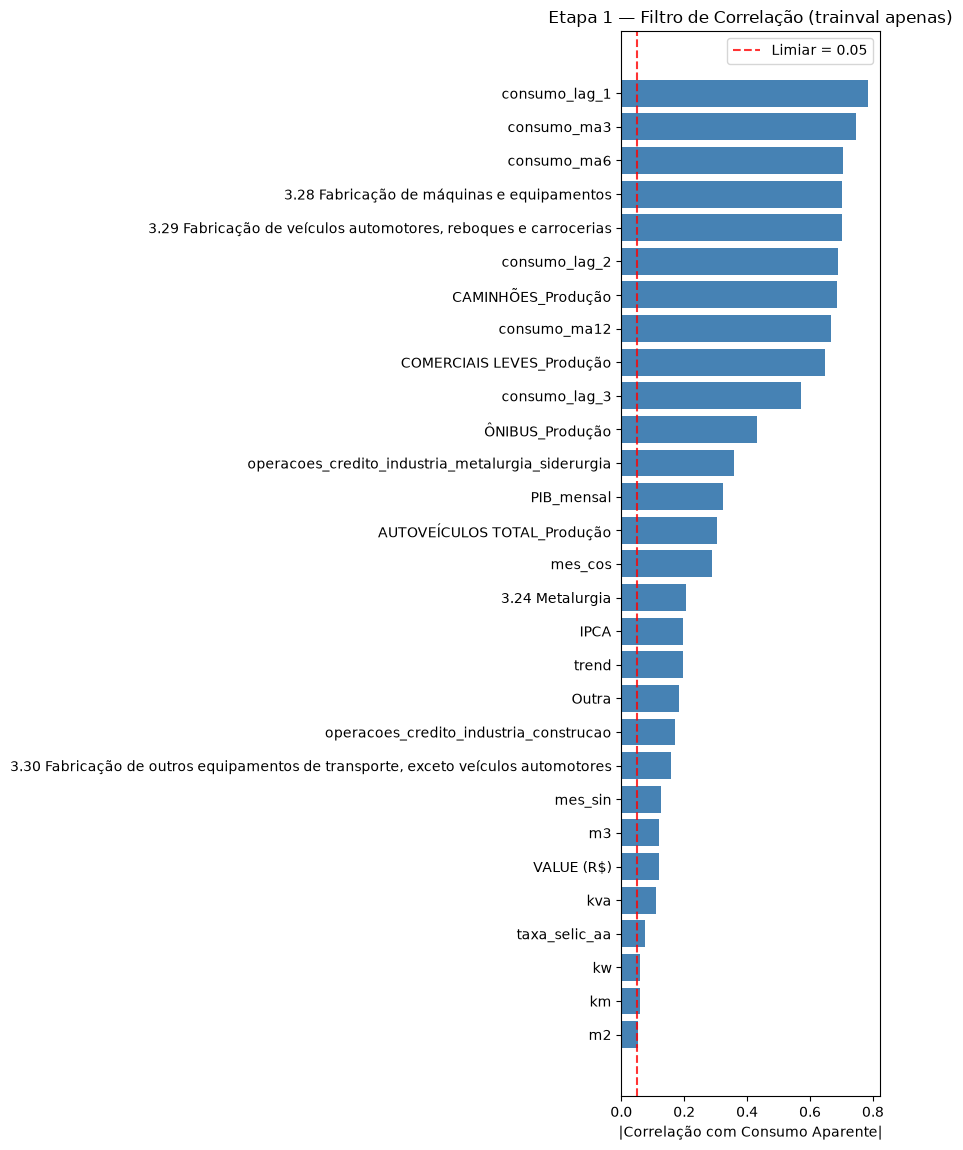

In [12]:
target_col = 'Consumo Aparente'

# Correlação computada apenas no trainval (< 2025) — sem vazar informação do test
_df_tv = df_tabela_mestre[df_tabela_mestre['Date'] < '2025-01-01'].copy()
FEATURE_COLS_ALL = [c for c in _df_tv.columns if c not in ['Date', target_col]]

corr_abs = _df_tv[FEATURE_COLS_ALL].corrwith(_df_tv[target_col]).abs().sort_values(ascending=False)

THRESHOLD_CORR = 0.05
features_drop_corr = corr_abs[corr_abs < THRESHOLD_CORR].index.tolist()
FEATURES_CORR      = corr_abs[corr_abs >= THRESHOLD_CORR].index.tolist()

print(f"Removidas por |corr| < {THRESHOLD_CORR} ({len(features_drop_corr)}):")
for f in features_drop_corr:
    print(f"  - {f:<70}  |corr| = {corr_abs[f]:.4f}")
print(f"\nMantidas após filtro: {len(FEATURES_CORR)}")
print(corr_abs[FEATURES_CORR].rename('|corr|').to_string())

# Visualização
fig, ax = plt.subplots(figsize=(9, max(4, len(FEATURES_CORR) * 0.40)))
colors_c = ['steelblue' if v >= THRESHOLD_CORR else 'lightcoral'
            for v in corr_abs[FEATURES_CORR][::-1]]
ax.barh(FEATURES_CORR[::-1], corr_abs[FEATURES_CORR][::-1], color=colors_c)
ax.axvline(THRESHOLD_CORR, color='red', linestyle='--', alpha=0.8, label=f'Limiar = {THRESHOLD_CORR}')
ax.set_xlabel('|Correlação com Consumo Aparente|')
ax.set_title('Etapa 1 — Filtro de Correlação (trainval apenas)')
ax.legend()
plt.tight_layout()
plt.savefig(f'./{path_secao_atual}/etapa1_correlation_filter.png', bbox_inches='tight')

keep_cols = ['Date', target_col] + FEATURES_CORR
df_tabela_mestre = df_tabela_mestre[keep_cols].sort_values('Date').reset_index(drop=True)
print(f"\nShape após Etapa 1: {df_tabela_mestre.shape}")

## 2. Modelagem Preditiva

In [13]:
df_tabela_mestre.head()

,Date,Consumo Aparente,consumo_lag_1,consumo_ma3,consumo_ma6,3.28 Fabricação de máquinas e equipamentos,"3.29 Fabricação de veículos automotores, reboques e carrocerias",consumo_lag_2,CAMINHÕES_Produção,consumo_ma12,COMERCIAIS LEVES_Produção,consumo_lag_3,ÔNIBUS_Produção,operacoes_credito_industria_metalurgia_siderurgia,PIB_mensal,AUTOVEÍCULOS TOTAL_Produção,mes_cos,3.24 Metalurgia,IPCA,trend,Outra,operacoes_credito_industria_construcao,"3.30 Fabricação de outros equipamentos de transporte, exceto veículos automotores",mes_sin,m3,VALUE (R$),kva,taxa_selic_aa,kw,km,m2
0,2014-01-01,927.046,769.865,949.954333,1005.247667,660.4378,967.89891,995.462,13776,991.862417,30088,1084.536,2431,48880,453274.2,237390,8.660254e-01,1598.927,0.55,12,5.273980e+05,107896,1304.52774,0.500000,67046.35,1.690171,150.0,10.690623,0.00,13224.64,7793517.45
1,2014-02-01,916.842,927.046,897.457667,979.529833,660.4378,967.89891,769.865,15174,993.624917,39125,995.462,3750,49258,455505.4,281627,5.000000e-01,1598.927,0.69,13,1.882174e+06,108950,1304.52774,0.866025,14043.68,1.702207,0.0,9.902948,60000.00,12370.35,4172578.38
2,2014-03-01,940.044,916.842,871.251000,954.759500,660.4378,967.89891,927.046,13844,997.158583,36211,769.865,3700,49832,477201.5,272754,6.123234e-17,1598.927,0.92,14,1.281491e+08,110130,1304.52774,1.000000,341809.82,1.425303,500.0,9.641534,51050.17,27611.11,3919601.95
3,2014-04-01,951.105,940.044,927.977333,938.965833,660.4378,967.89891,916.842,12314,990.581250,42551,927.046,3395,49751,479725.1,277091,-5.000000e-01,1598.927,0.67,15,2.380034e+06,111799,1304.52774,0.866025,30289.10,1.488117,0.0,10.296141,56000.00,63868.05,5182198.92
4,2014-05-01,981.738,951.105,935.997000,916.727333,660.4378,967.89891,940.044,12695,983.580083,40144,916.842,3388,49331,481271.5,281355,-8.660254e-01,1598.927,0.46,16,2.394161e+06,113783,1304.52774,0.500000,308819.95,1.504061,0.0,10.954329,0.00,79957.55,5714652.20


In [14]:
df_tabela_mestre.tail()

,Date,Consumo Aparente,consumo_lag_1,consumo_ma3,consumo_ma6,3.28 Fabricação de máquinas e equipamentos,"3.29 Fabricação de veículos automotores, reboques e carrocerias",consumo_lag_2,CAMINHÕES_Produção,consumo_ma12,COMERCIAIS LEVES_Produção,consumo_lag_3,ÔNIBUS_Produção,operacoes_credito_industria_metalurgia_siderurgia,PIB_mensal,AUTOVEÍCULOS TOTAL_Produção,mes_cos,3.24 Metalurgia,IPCA,trend,Outra,operacoes_credito_industria_construcao,"3.30 Fabricação de outros equipamentos de transporte, exceto veículos automotores",mes_sin,m3,VALUE (R$),kva,taxa_selic_aa,kw,km,m2
144,2026-01-01,741.387,681.715,792.240667,852.023333,681.70730,679.80334,787.713,6813,867.735500,30782,907.294,1884,54982,1027025.9,163672,8.660254e-01,1270.35700,0.33,156,2.630901e+08,162797,584.92357,0.500000,8419728.65,5.337419,316414.61,14.843349,4404808.76,57944.32,36277795.83
145,2026-02-01,763.804,741.387,736.938333,814.792500,756.72097,847.32653,681.715,7797,857.849500,41499,787.713,2786,55442,1051261.2,207028,5.000000e-01,1162.92176,0.70,157,4.937053e+08,164284,526.51414,0.866025,3078838.56,5.200011,264718.70,12.682503,212103.47,255940.31,17534956.13
146,2026-03-01,981.477,763.804,728.968667,797.995833,856.34190,1022.72777,741.387,11133,851.857417,50214,681.715,3145,56877,1172691.8,263608,6.123234e-17,1158.69850,0.88,158,8.297629e+08,165359,574.39457,1.000000,25746007.80,5.230982,206697.30,15.526362,189748.23,13122983.15,33425577.58
147,2026-04-01,888.898,981.477,828.889333,810.565000,700.60923,955.24230,763.804,9673,856.667500,42792,741.387,3095,53760,1145657.0,238550,-5.000000e-01,1206.50653,0.67,159,2.408977e+09,165785,529.95676,0.866025,19157831.21,5.032475,815003.28,13.893348,64256.91,605488.71,33741187.44
148,2026-05-01,816.143,888.898,878.059667,807.499000,700.60923,955.24230,981.477,10488,857.866833,38872,763.804,2975,53760,1142240.6,253519,-8.660254e-01,1206.50653,0.58,160,2.584850e+08,165785,529.95676,0.500000,30134050.45,4.983100,21401.30,13.623245,14959.73,222310.41,42513299.30


In [15]:
df_tabela_mestre.shape

(149, 31)

## 3. Divisão Treino / Val / Teste

In [16]:
# Treino: histórico completo antes de 2024 (usa todos os anos disponíveis)
# Val:    2024 — usado apenas para early stopping no Optuna (nunca visto pelo tuning como test)
# Teste:  2025 — mantido completamente isolado até a avaliação final
df_test     = df_tabela_mestre[df_tabela_mestre['Date'] >= '2025-01-01'].copy().reset_index(drop=True)
df_val      = df_tabela_mestre[(df_tabela_mestre['Date'] >= '2024-01-01') & (df_tabela_mestre['Date'] < '2025-01-01')].copy().reset_index(drop=True)
df_train    = df_tabela_mestre[df_tabela_mestre['Date'] < '2024-01-01'].copy().reset_index(drop=True)
df_trainval = df_tabela_mestre[df_tabela_mestre['Date'] < '2025-01-01'].copy().reset_index(drop=True)

print(f"Treino:     {df_train.shape[0]:3d} obs  ({df_train['Date'].min().date()} → {df_train['Date'].max().date()})")
print(f"Validação:  {df_val.shape[0]:3d} obs  ({df_val['Date'].min().date()} → {df_val['Date'].max().date()})")
print(f"Teste:      {df_test.shape[0]:3d} obs  ({df_test['Date'].min().date()} → {df_test['Date'].max().date()})")

Treino:     120 obs  (2014-01-01 → 2023-12-01)
Validação:   12 obs  (2024-01-01 → 2024-12-01)
Teste:       17 obs  (2025-01-01 → 2026-05-01)


## Pesos por Recência (Decaimento Exponencial)

In [17]:
lambda_fator = 0.95

# Pesos para treino isolado (usado no Optuna, com early stopping em val)
df_train_ord  = df_train.sort_values('Date', ascending=False).reset_index(drop=True)
pesos_train   = (lambda_fator ** df_train_ord.index).values[::-1]

# Pesos para trainval (usado no modelo final)
df_tv_ord     = df_trainval.sort_values('Date', ascending=False).reset_index(drop=True)
pesos_trainval = (lambda_fator ** df_tv_ord.index).values[::-1]

print(f"Peso mínimo (obs mais antiga):  {pesos_train.min():.4f}")
print(f"Peso máximo (obs mais recente): {pesos_train.max():.4f}")

Peso mínimo (obs mais antiga):  0.0022
Peso máximo (obs mais recente): 1.0000


In [18]:
feature_cols_model = [c for c in df_train.columns if c not in ['Date', target_col]]

X_train    = df_train[feature_cols_model]
y_train    = df_train[target_col]

X_val      = df_val[feature_cols_model]
y_val      = df_val[target_col]

X_test     = df_test[feature_cols_model]
y_test     = df_test[target_col]

X_trainval = df_trainval[feature_cols_model]
y_trainval = df_trainval[target_col]

print(f"X_train:    {X_train.shape}")
print(f"X_val:      {X_val.shape}")
print(f"X_test:     {X_test.shape}")

X_train:    (120, 29)
X_val:      (12, 29)
X_test:     (17, 29)


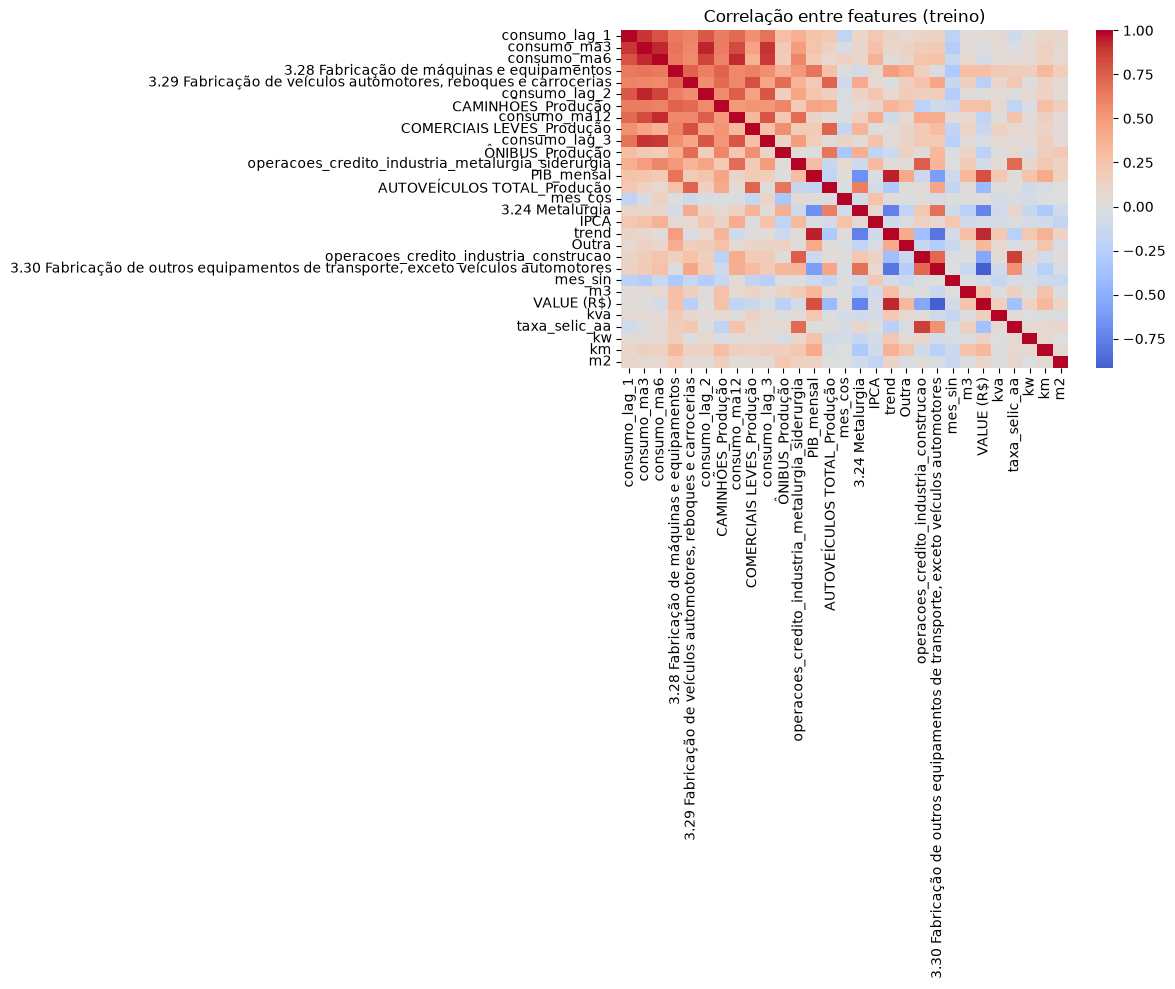

In [19]:
plt.figure(figsize=(12, 10))
sns.heatmap(X_train.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Correlação entre features (treino)')
plt.tight_layout()
plt.savefig(f'./{path_secao_atual}/correlation_train.png', bbox_inches='tight')

In [20]:
df_test.head()

,Date,Consumo Aparente,consumo_lag_1,consumo_ma3,consumo_ma6,3.28 Fabricação de máquinas e equipamentos,"3.29 Fabricação de veículos automotores, reboques e carrocerias",consumo_lag_2,CAMINHÕES_Produção,consumo_ma12,COMERCIAIS LEVES_Produção,consumo_lag_3,ÔNIBUS_Produção,operacoes_credito_industria_metalurgia_siderurgia,PIB_mensal,AUTOVEÍCULOS TOTAL_Produção,mes_cos,3.24 Metalurgia,IPCA,trend,Outra,operacoes_credito_industria_construcao,"3.30 Fabricação de outros equipamentos de transporte, exceto veículos automotores",mes_sin,m3,VALUE (R$),kva,taxa_selic_aa,kw,km,m2
0,2025-01-01,860.019,697.641,847.050667,899.857000,822.00749,829.50313,877.965,8041,863.592833,30754,965.546,1806,53299,957383.9,181405,8.660254e-01,1161.03748,0.16,144,1.219462e+08,142190,485.84519,0.500000,640828.20,6.021173,54213923.87,12.816456,172517.88,135585.95,3.421761e+07
1,2025-02-01,835.709,860.019,811.875000,885.353333,840.61394,892.80085,697.641,11970,870.503417,42384,877.965,2485,53078,995276.2,222641,5.000000e-01,1150.68202,1.31,145,2.571811e+08,144163,510.17106,0.866025,7632276.27,5.765045,66196.00,12.548696,4145707.93,54361.16,1.182539e+08
2,2025-03-01,923.756,835.709,797.789667,858.075500,903.90666,804.95627,860.019,11720,875.856500,36217,697.641,2881,55179,1072062.7,194775,6.123234e-17,1293.36977,0.56,146,1.405650e+08,146445,499.19809,1.000000,5600850.37,5.746216,58428.81,12.148147,941468.89,94316.74,2.805906e+09
3,2025-04-01,874.506,923.756,873.161333,860.106000,870.19687,868.94550,835.709,11020,884.466750,45326,860.019,2874,52386,1087637.4,232814,-5.000000e-01,1255.71112,0.43,147,3.769977e+08,148013,602.83832,0.866025,3125428.03,5.783085,19930.28,13.488414,30446.56,2567499.61,2.278937e+07
4,2025-05-01,887.499,874.506,877.990333,844.932667,950.17380,851.82587,923.756,12327,885.306333,44477,835.709,2920,53588,1061998.2,220078,-8.660254e-01,1302.63000,0.26,148,1.123480e+08,149886,592.41836,0.500000,13784764.20,5.666781,320886.80,14.571181,3634673.10,126837.20,9.677494e+07


In [21]:
df_test.shape

(17, 31)

In [22]:
X_train.head()

,consumo_lag_1,consumo_ma3,consumo_ma6,3.28 Fabricação de máquinas e equipamentos,"3.29 Fabricação de veículos automotores, reboques e carrocerias",consumo_lag_2,CAMINHÕES_Produção,consumo_ma12,COMERCIAIS LEVES_Produção,consumo_lag_3,ÔNIBUS_Produção,operacoes_credito_industria_metalurgia_siderurgia,PIB_mensal,AUTOVEÍCULOS TOTAL_Produção,mes_cos,3.24 Metalurgia,IPCA,trend,Outra,operacoes_credito_industria_construcao,"3.30 Fabricação de outros equipamentos de transporte, exceto veículos automotores",mes_sin,m3,VALUE (R$),kva,taxa_selic_aa,kw,km,m2
0,769.865,949.954333,1005.247667,660.4378,967.89891,995.462,13776,991.862417,30088,1084.536,2431,48880,453274.2,237390,8.660254e-01,1598.927,0.55,12,5.273980e+05,107896,1304.52774,0.500000,67046.35,1.690171,150.0,10.690623,0.00,13224.64,7793517.45
1,927.046,897.457667,979.529833,660.4378,967.89891,769.865,15174,993.624917,39125,995.462,3750,49258,455505.4,281627,5.000000e-01,1598.927,0.69,13,1.882174e+06,108950,1304.52774,0.866025,14043.68,1.702207,0.0,9.902948,60000.00,12370.35,4172578.38
2,916.842,871.251000,954.759500,660.4378,967.89891,927.046,13844,997.158583,36211,769.865,3700,49832,477201.5,272754,6.123234e-17,1598.927,0.92,14,1.281491e+08,110130,1304.52774,1.000000,341809.82,1.425303,500.0,9.641534,51050.17,27611.11,3919601.95
3,940.044,927.977333,938.965833,660.4378,967.89891,916.842,12314,990.581250,42551,927.046,3395,49751,479725.1,277091,-5.000000e-01,1598.927,0.67,15,2.380034e+06,111799,1304.52774,0.866025,30289.10,1.488117,0.0,10.296141,56000.00,63868.05,5182198.92
4,951.105,935.997000,916.727333,660.4378,967.89891,940.044,12695,983.580083,40144,916.842,3388,49331,481271.5,281355,-8.660254e-01,1598.927,0.46,16,2.394161e+06,113783,1304.52774,0.500000,308819.95,1.504061,0.0,10.954329,0.00,79957.55,5714652.20


In [23]:
X_test.head()

,consumo_lag_1,consumo_ma3,consumo_ma6,3.28 Fabricação de máquinas e equipamentos,"3.29 Fabricação de veículos automotores, reboques e carrocerias",consumo_lag_2,CAMINHÕES_Produção,consumo_ma12,COMERCIAIS LEVES_Produção,consumo_lag_3,ÔNIBUS_Produção,operacoes_credito_industria_metalurgia_siderurgia,PIB_mensal,AUTOVEÍCULOS TOTAL_Produção,mes_cos,3.24 Metalurgia,IPCA,trend,Outra,operacoes_credito_industria_construcao,"3.30 Fabricação de outros equipamentos de transporte, exceto veículos automotores",mes_sin,m3,VALUE (R$),kva,taxa_selic_aa,kw,km,m2
0,697.641,847.050667,899.857000,822.00749,829.50313,877.965,8041,863.592833,30754,965.546,1806,53299,957383.9,181405,8.660254e-01,1161.03748,0.16,144,1.219462e+08,142190,485.84519,0.500000,640828.20,6.021173,54213923.87,12.816456,172517.88,135585.95,3.421761e+07
1,860.019,811.875000,885.353333,840.61394,892.80085,697.641,11970,870.503417,42384,877.965,2485,53078,995276.2,222641,5.000000e-01,1150.68202,1.31,145,2.571811e+08,144163,510.17106,0.866025,7632276.27,5.765045,66196.00,12.548696,4145707.93,54361.16,1.182539e+08
2,835.709,797.789667,858.075500,903.90666,804.95627,860.019,11720,875.856500,36217,697.641,2881,55179,1072062.7,194775,6.123234e-17,1293.36977,0.56,146,1.405650e+08,146445,499.19809,1.000000,5600850.37,5.746216,58428.81,12.148147,941468.89,94316.74,2.805906e+09
3,923.756,873.161333,860.106000,870.19687,868.94550,835.709,11020,884.466750,45326,860.019,2874,52386,1087637.4,232814,-5.000000e-01,1255.71112,0.43,147,3.769977e+08,148013,602.83832,0.866025,3125428.03,5.783085,19930.28,13.488414,30446.56,2567499.61,2.278937e+07
4,874.506,877.990333,844.932667,950.17380,851.82587,923.756,12327,885.306333,44477,835.709,2920,53588,1061998.2,220078,-8.660254e-01,1302.63000,0.26,148,1.123480e+08,149886,592.41836,0.500000,13784764.20,5.666781,320886.80,14.571181,3634673.10,126837.20,9.677494e+07


In [24]:
y_train.head()

0    927.046
1    916.842
2    940.044
3    951.105
4    981.738
Name: Consumo Aparente, dtype: float64

In [25]:
y_test.head()

0    860.019
1    835.709
2    923.756
3    874.506
4    887.499
Name: Consumo Aparente, dtype: float64

## Seleção de Features — Etapa 2: Permutation Importance no Val Set

Treina um XGBoost base no conjunto de treino e mede, para cada feature, o quanto o MAPE no val (2024) piora quando ela é permutada aleatoriamente. Features com importância ≤ 0 não contribuem fora do treino e são descartadas.

Permutation Importance no Val (positivo = permutação piora o MAPE = feature é útil):
                                                                          Feature  Importance_mean  Importance_std
                                                                  3.24 Metalurgia         0.011772        0.006388
                                                                          mes_cos         0.009951        0.005354
                                                               CAMINHÕES_Produção         0.004652        0.003645
                                                                               m2         0.001959        0.001456
                                                                    consumo_lag_1         0.001593        0.003816
                                                                               kw         0.000658        0.000313
3.30 Fabricação de outros equipamentos de transporte, exceto veículos automotores         0.000603        0.00

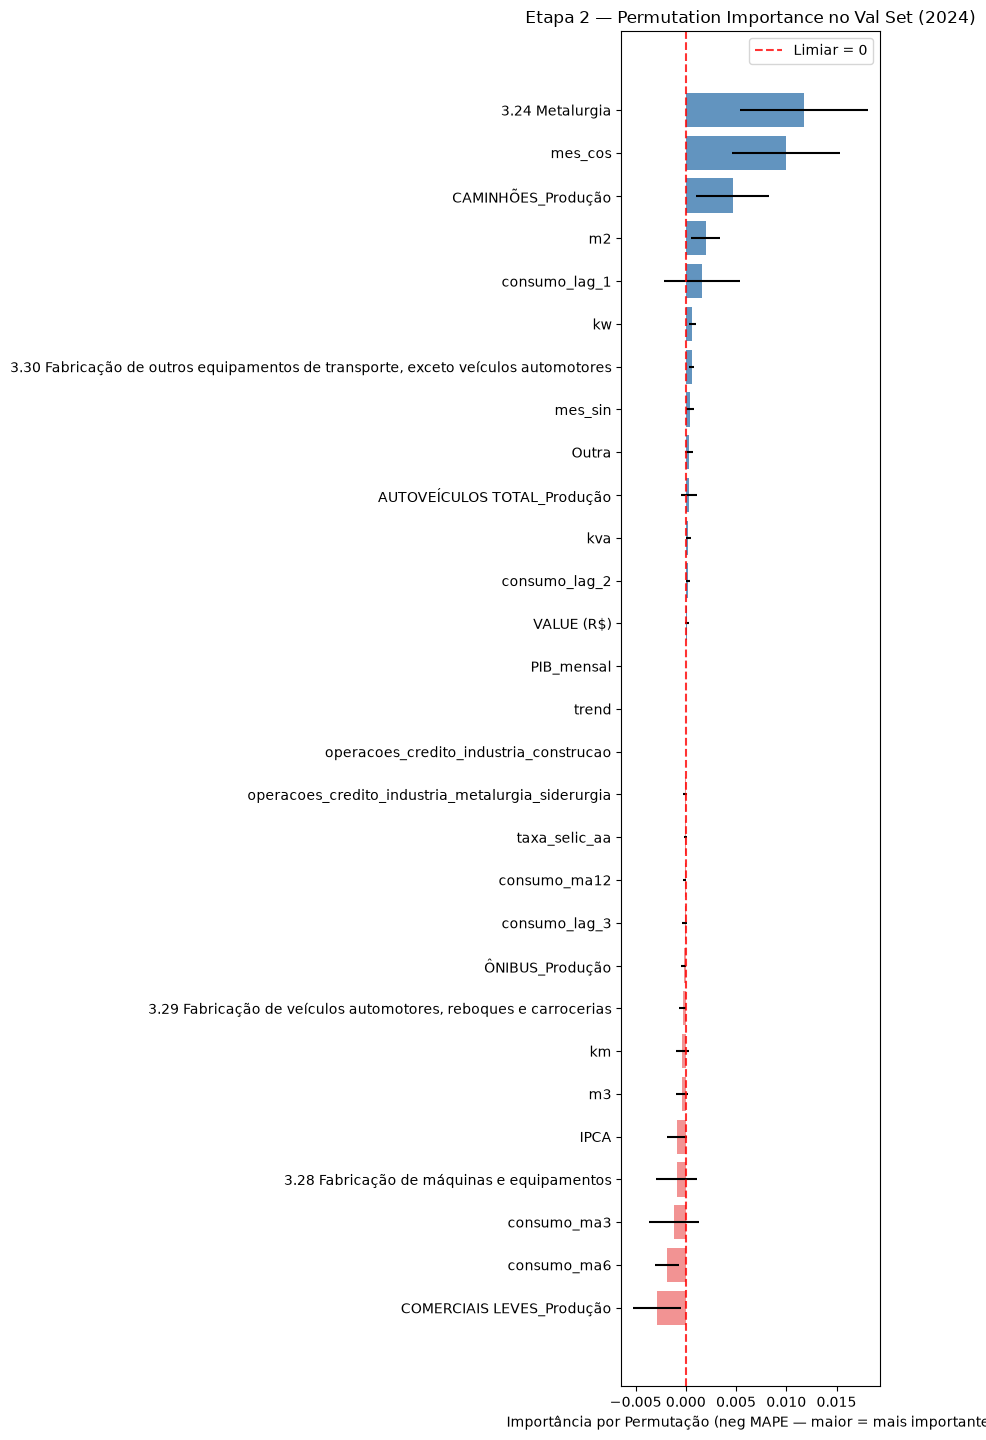

In [26]:
from sklearn.inspection import permutation_importance as perm_imp

# Modelo base conservador — serve apenas para guiar a seleção, não é o modelo final
_sel_model = XGBRegressor(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.5, reg_lambda=1.0, random_state=0,
)
_sel_model.fit(X_train, y_train, sample_weight=pesos_train)

# n_repeats=50: cada feature é permutada 50 vezes → média e desvio estáveis mesmo com val pequeno (12 obs)
result_perm = perm_imp(
    _sel_model, X_val, y_val,
    n_repeats=50,
    scoring='neg_mean_absolute_percentage_error',
    random_state=0,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    'Feature':         list(X_train.columns),
    'Importance_mean': result_perm.importances_mean,
    'Importance_std':  result_perm.importances_std,
}).sort_values('Importance_mean', ascending=False).reset_index(drop=True)

print("Permutation Importance no Val (positivo = permutação piora o MAPE = feature é útil):")
print(perm_df.to_string(index=False))

# Visualização com barras de erro
fig, ax = plt.subplots(figsize=(9, max(4, len(perm_df) * 0.50)))
colors_pi = ['steelblue' if v > 0 else 'lightcoral' for v in perm_df['Importance_mean'][::-1]]
ax.barh(
    perm_df['Feature'][::-1],
    perm_df['Importance_mean'][::-1],
    xerr=perm_df['Importance_std'][::-1],
    color=colors_pi, alpha=0.85,
)
ax.axvline(0, color='red', linestyle='--', alpha=0.8, label='Limiar = 0')
ax.set_xlabel('Importância por Permutação (neg MAPE — maior = mais importante)')
ax.set_title('Etapa 2 — Permutation Importance no Val Set (2024)')
ax.legend()
plt.tight_layout()
plt.savefig(f'./{path_secao_atual}/etapa2_permutation_importance.png', bbox_inches='tight')

In [27]:
# Manter features onde a permutação degrada o MAPE (importance_mean > 0)
SELECTED_FEATURES_PERM = perm_df[perm_df['Importance_mean'] > 0]['Feature'].tolist()

# Garantir que os lags do target de curto prazo sempre entrem
# (podem ser descartados por correlação mútua entre si)
FORCE_INCLUDE = [f for f in ['consumo_lag_1', 'consumo_lag_2', 'consumo_ma3']
                 if f in X_train.columns and f not in SELECTED_FEATURES_PERM]
SELECTED_FEATURES_PERM = FORCE_INCLUDE + SELECTED_FEATURES_PERM

removed_perm = [f for f in X_train.columns if f not in SELECTED_FEATURES_PERM]
print(f"Etapa 2 — removidas ({len(removed_perm)}): {removed_perm or 'nenhuma'}")
print(f"Etapa 2 — mantidas  ({len(SELECTED_FEATURES_PERM)}): {SELECTED_FEATURES_PERM}")

# Atualizar todas as matrizes X com o set final de features
X_train    = X_train[SELECTED_FEATURES_PERM]
X_val      = X_val[SELECTED_FEATURES_PERM]
X_test     = X_test[SELECTED_FEATURES_PERM]
X_trainval = X_trainval[SELECTED_FEATURES_PERM]

print(f"\nShapes finais: X_train={X_train.shape}  X_val={X_val.shape}  X_test={X_test.shape}")

Etapa 2 — removidas (14): ['consumo_ma6', '3.28 Fabricação de máquinas e equipamentos', '3.29 Fabricação de veículos automotores, reboques e carrocerias', 'consumo_ma12', 'COMERCIAIS LEVES_Produção', 'consumo_lag_3', 'ÔNIBUS_Produção', 'operacoes_credito_industria_metalurgia_siderurgia', 'IPCA', 'trend', 'operacoes_credito_industria_construcao', 'm3', 'taxa_selic_aa', 'km']
Etapa 2 — mantidas  (15): ['consumo_ma3', '3.24 Metalurgia', 'mes_cos', 'CAMINHÕES_Produção', 'm2', 'consumo_lag_1', 'kw', '3.30 Fabricação de outros equipamentos de transporte, exceto veículos automotores', 'mes_sin', 'Outra', 'AUTOVEÍCULOS TOTAL_Produção', 'kva', 'consumo_lag_2', 'VALUE (R$)', 'PIB_mensal']

Shapes finais: X_train=(120, 15)  X_val=(12, 15)  X_test=(17, 15)


# Ajustar o modelo

## Baseline: SARIMA

Grid search por AIC sobre um espaço compacto de ordens. O SARIMA usa apenas a série temporal do target, sem features externas. Serve como referência mínima: se o XGBoost não bater o SARIMA, há problema na modelagem.

In [28]:
import itertools
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

train_ts    = df_train.set_index('Date')[target_col].sort_index()
trainval_ts = df_trainval.set_index('Date')[target_col].sort_index()
val_ts      = df_val.set_index('Date')[target_col].sort_index()
test_ts     = df_test.set_index('Date')[target_col].sort_index()

# Espaço de busca: 36 combinações (p,d,q) x (P,D,Q,12)
_p = [0, 1, 2]
_d = [1]
_q = [0, 1, 2]
_P = [0, 1]
_D = [1]
_Q = [0, 1]
_s = 12

best_aic   = np.inf
sarima_order         = None
sarima_seasonal_order = None

print("Grid search SARIMA — seleção por AIC no conjunto de treino...")
for p, d, q, P, D, Q in itertools.product(_p, _d, _q, _P, _D, _Q):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            res = SARIMAX(
                train_ts,
                order=(p, d, q),
                seasonal_order=(P, D, Q, _s),
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False)
        if res.aic < best_aic:
            best_aic             = res.aic
            sarima_order         = (p, d, q)
            sarima_seasonal_order = (P, D, Q, _s)
    except Exception:
        continue

print(f"Melhor ordem:          SARIMA{sarima_order}×{sarima_seasonal_order}")
print(f"AIC (treino):          {best_aic:.2f}")

Grid search SARIMA — seleção por AIC no conjunto de treino...
Melhor ordem:          SARIMA(0, 1, 2)×(0, 1, 1, 12)
AIC (treino):          1029.47


In [29]:
# --- Ajuste em treino → previsão para val (espelha o protocolo do XGBoost) ---
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sarima_fit_train = SARIMAX(
        train_ts,
        order=sarima_order,
        seasonal_order=sarima_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)

sarima_val_pred = sarima_fit_train.forecast(steps=len(val_ts))
sarima_val_pred.index = val_ts.index

# --- Ajuste em trainval → previsão para test (modelo final, igual ao XGBoost) ---
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sarima_fit_trainval = SARIMAX(
        trainval_ts,
        order=sarima_order,
        seasonal_order=sarima_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)

sarima_test_pred = sarima_fit_trainval.forecast(steps=len(test_ts))
sarima_test_pred.index = test_ts.index

# --- Métricas SARIMA ---
sarima_r2_val    = np.round(r2_score(val_ts,  sarima_val_pred),  4)
sarima_mae_val   = np.round(mean_absolute_error(val_ts,  sarima_val_pred), 4)
sarima_mape_val  = np.round(mean_absolute_percentage_error(val_ts,  sarima_val_pred), 4)

sarima_r2_test   = np.round(r2_score(test_ts, sarima_test_pred), 4)
sarima_mae_test  = np.round(mean_absolute_error(test_ts, sarima_test_pred), 4)
sarima_mape_test = np.round(mean_absolute_percentage_error(test_ts, sarima_test_pred), 4)

print(f"SARIMA{sarima_order}×{sarima_seasonal_order} — resultados:")
print(f"{'Conjunto':<14} {'R²':>6}  {'MAE':>8}  {'MAPE':>7}")
print(f"{'Val  (2024)':<14} {sarima_r2_val:>6.4f}  {sarima_mae_val:>8.3f}  {sarima_mape_val:>7.4f}")
print(f"{'Teste (2025)':<14} {sarima_r2_test:>6.4f}  {sarima_mae_test:>8.3f}  {sarima_mape_test:>7.4f}")

SARIMA(0, 1, 2)×(0, 1, 1, 12) — resultados:
Conjunto           R²       MAE     MAPE
Val  (2024)    0.4795    48.656   0.0540
Teste (2025)   0.6524    39.531   0.0471


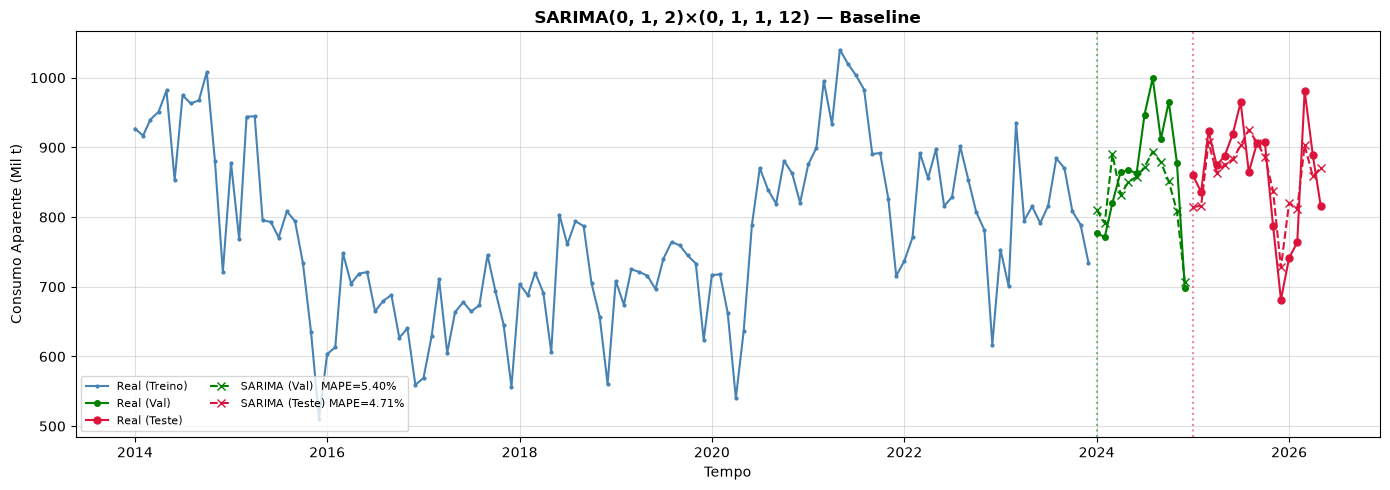

In [30]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train_ts.index, train_ts.values, label='Real (Treino)', color='steelblue', marker='o', markersize=2)
ax.plot(val_ts.index,   val_ts.values,   label='Real (Val)',    color='green',     marker='o', markersize=4)
ax.plot(test_ts.index,  test_ts.values,  label='Real (Teste)',  color='crimson',   marker='o', markersize=5)

ax.plot(sarima_val_pred.index,  sarima_val_pred.values,  label=f'SARIMA (Val)  MAPE={sarima_mape_val:.2%}',  color='green',   linestyle='--', marker='x', markersize=6)
ax.plot(sarima_test_pred.index, sarima_test_pred.values, label=f'SARIMA (Teste) MAPE={sarima_mape_test:.2%}', color='crimson', linestyle='--', marker='x', markersize=6)

ax.axvline(pd.Timestamp('2024-01-01'), color='green',  linestyle=':', alpha=0.5)
ax.axvline(pd.Timestamp('2025-01-01'), color='crimson', linestyle=':', alpha=0.5)

ax.set_title(f'SARIMA{sarima_order}×{sarima_seasonal_order} — Baseline', fontsize=12, fontweight='bold')
ax.set_xlabel('Tempo')
ax.set_ylabel('Consumo Aparente (Mil t)')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(f'./{path_secao_atual}/sarima_baseline_r2_val_{sarima_r2_val}_r2_test_{sarima_r2_test}.png', bbox_inches='tight')

In [31]:
def objective(trial):
    param = {
        'n_estimators':       trial.suggest_int('n_estimators', 50, 600),
        'max_depth':          trial.suggest_int('max_depth', 2, 5),
        'learning_rate':      trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample':          trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'min_child_weight':   trial.suggest_int('min_child_weight', 3, 15),
        'gamma':              trial.suggest_float('gamma', 1e-4, 5.0, log=True),
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state':       0,
        'early_stopping_rounds': 20,
    }
    model_opt = XGBRegressor(**param)
    # eval_set usa VAL (não test!) — early stopping sem leakage do conjunto de teste
    model_opt.fit(
        X_train, y_train,
        sample_weight=pesos_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    y_pred_val = model_opt.predict(X_val)
    return mean_squared_error(y_val, y_pred_val)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print('Melhores parâmetros (Optuna):')
print(study.best_params)
print(f'Menor MSE (val): {study.best_value:.2f}')

# Walk-forward CV — avaliação mais robusta usando todo o histórico trainval
tscv_wf = TimeSeriesSplit(n_splits=8, test_size=6)
cv_mapes = []
for fold, (tr_idx, vl_idx) in enumerate(tscv_wf.split(X_trainval)):
    X_cv_tr, X_cv_vl = X_trainval.iloc[tr_idx], X_trainval.iloc[vl_idx]
    y_cv_tr, y_cv_vl = y_trainval.iloc[tr_idx], y_trainval.iloc[vl_idx]
    w_cv_tr = pesos_trainval[tr_idx]
    m = XGBRegressor(**{k: v for k, v in study.best_params.items()}, random_state=0)
    m.fit(X_cv_tr, y_cv_tr, sample_weight=w_cv_tr)
    fold_mape = mean_absolute_percentage_error(y_cv_vl, m.predict(X_cv_vl))
    cv_mapes.append(fold_mape)
    print(f"  Fold {fold+1}: MAPE = {fold_mape:.4f}")

print(f"\nWalk-forward CV MAPE: {np.mean(cv_mapes):.4f} ± {np.std(cv_mapes):.4f}")

# Modelo final: treinado em trainval completo, avaliado no test (2025)
best_params_clean = {k: v for k, v in study.best_params.items()}
best_model = XGBRegressor(**best_params_clean, random_state=0)
best_model.fit(X_trainval, y_trainval, sample_weight=pesos_trainval)

y_pred_train_opt = best_model.predict(X_train)
y_pred_val_opt   = best_model.predict(X_val)
y_pred_test_opt  = best_model.predict(X_test)

mse_train_opt  = np.round(mean_squared_error(y_train, y_pred_train_opt), 4)
r2_train_opt   = np.round(r2_score(y_train, y_pred_train_opt), 4)
mae_train_opt  = np.round(mean_absolute_error(y_train, y_pred_train_opt), 4)
mape_train_opt = np.round(mean_absolute_percentage_error(y_train, y_pred_train_opt), 4)

mse_val_opt    = np.round(mean_squared_error(y_val, y_pred_val_opt), 4)
r2_val_opt     = np.round(r2_score(y_val, y_pred_val_opt), 4)
mae_val_opt    = np.round(mean_absolute_error(y_val, y_pred_val_opt), 4)
mape_val_opt   = np.round(mean_absolute_percentage_error(y_val, y_pred_val_opt), 4)

mse_test_opt   = np.round(mean_squared_error(y_test, y_pred_test_opt), 4)
r2_test_opt    = np.round(r2_score(y_test, y_pred_test_opt), 4)
mae_test_opt   = np.round(mean_absolute_error(y_test, y_pred_test_opt), 4)
mape_test_opt  = np.round(mean_absolute_percentage_error(y_test, y_pred_test_opt), 4)

[I 2026-06-30 16:38:57,722] A new study created in memory with name: no-name-aba186e3-0498-46a6-a3ee-a0e06b7d00a3
[I 2026-06-30 16:38:57,766] Trial 0 finished with value: 8964.763853795195 and parameters: {'n_estimators': 397, 'max_depth': 5, 'learning_rate': 0.018396660744090586, 'subsample': 0.5357242879638332, 'colsample_bytree': 0.7354500073614242, 'min_child_weight': 6, 'gamma': 3.204422469688212, 'reg_alpha': 0.5114306289016752, 'reg_lambda': 0.004042594438592784}. Best is trial 0 with value: 8964.763853795195.
[I 2026-06-30 16:38:57,786] Trial 1 finished with value: 9658.123524558046 and parameters: {'n_estimators': 553, 'max_depth': 4, 'learning_rate': 0.005919615349999919, 'subsample': 0.6103777376188787, 'colsample_bytree': 0.6353119544100982, 'min_child_weight': 10, 'gamma': 4.304024913982107, 'reg_alpha': 0.0019350194454764481, 'reg_lambda': 2.203602306854273}. Best is trial 0 with value: 8964.763853795195.
[I 2026-06-30 16:38:58,198] Trial 2 finished with value: 2880.84648

Melhores parâmetros (Optuna):
{'n_estimators': 423, 'max_depth': 5, 'learning_rate': 0.030215066236801057, 'subsample': 0.8756723959281996, 'colsample_bytree': 0.8199198111122046, 'min_child_weight': 4, 'gamma': 1.1208081220629698, 'reg_alpha': 0.004765953058194387, 'reg_lambda': 0.0150726927712051}
Menor MSE (val): 1207.01
  Fold 1: MAPE = 0.2273
  Fold 2: MAPE = 0.1242
  Fold 3: MAPE = 0.0651
  Fold 4: MAPE = 0.0896
  Fold 5: MAPE = 0.0714
  Fold 6: MAPE = 0.0486
  Fold 7: MAPE = 0.0439
  Fold 8: MAPE = 0.0590

Walk-forward CV MAPE: 0.0911 ± 0.0568


In [32]:
print('-' * 55)
print('--- Resultados — XGBoost + Optuna ---')
print(f'{"Conjunto":<12} {"R²":>6}  {"MSE":>10}  {"MAE":>8}  {"MAPE":>7}')
print(f'{"Treino":<12} {r2_train_opt:>6.4f}  {mse_train_opt:>10.2f}  {mae_train_opt:>8.3f}  {mape_train_opt:>7.4f}')
print(f'{"Val (2024)":<12} {r2_val_opt:>6.4f}  {mse_val_opt:>10.2f}  {mae_val_opt:>8.3f}  {mape_val_opt:>7.4f}')
print(f'{"Teste (2025)":<12} {r2_test_opt:>6.4f}  {mse_test_opt:>10.2f}  {mae_test_opt:>8.3f}  {mape_test_opt:>7.4f}')
print(f'\nWalk-forward CV MAPE: {np.mean(cv_mapes):.4f} ± {np.std(cv_mapes):.4f}')

-------------------------------------------------------
--- Resultados — XGBoost + Optuna ---
Conjunto         R²         MSE       MAE     MAPE
Treino       0.7389     3696.21    43.085   0.0603
Val (2024)   0.9962       26.25     3.920   0.0048
Teste (2025) 0.2715     4384.62    49.105   0.0567

Walk-forward CV MAPE: 0.0911 ± 0.0568


### Comparação: SARIMA (baseline) vs XGBoost

In [33]:
comparison = pd.DataFrame({
    'Modelo':   [f'SARIMA{sarima_order}×{sarima_seasonal_order}', f'SARIMA{sarima_order}×{sarima_seasonal_order}',
                 'XGBoost', 'XGBoost'],
    'Conjunto': ['Val (2024)', 'Teste (2025)', 'Val (2024)', 'Teste (2025)'],
    'R²':       [sarima_r2_val,   sarima_r2_test,  r2_val_opt,   r2_test_opt],
    'MAE':      [sarima_mae_val,  sarima_mae_test, mae_val_opt,  mae_test_opt],
    'MAPE':     [sarima_mape_val, sarima_mape_test, mape_val_opt, mape_test_opt],
})
print(comparison.to_string(index=False))

# XGBoost vence o baseline?
delta_mape_test = mape_test_opt - sarima_mape_test
verdict = "✓ XGBoost supera o SARIMA" if delta_mape_test < 0 else "✗ XGBoost NÃO supera o SARIMA"
print(f"\n{verdict} no teste (ΔMAPE = {delta_mape_test:+.4f})")

                       Modelo     Conjunto     R²     MAE   MAPE
SARIMA(0, 1, 2)×(0, 1, 1, 12)   Val (2024) 0.4795 48.6563 0.0540
SARIMA(0, 1, 2)×(0, 1, 1, 12) Teste (2025) 0.6524 39.5313 0.0471
                      XGBoost   Val (2024) 0.9962  3.9201 0.0048
                      XGBoost Teste (2025) 0.2715 49.1054 0.0567

✗ XGBoost NÃO supera o SARIMA no teste (ΔMAPE = +0.0096)


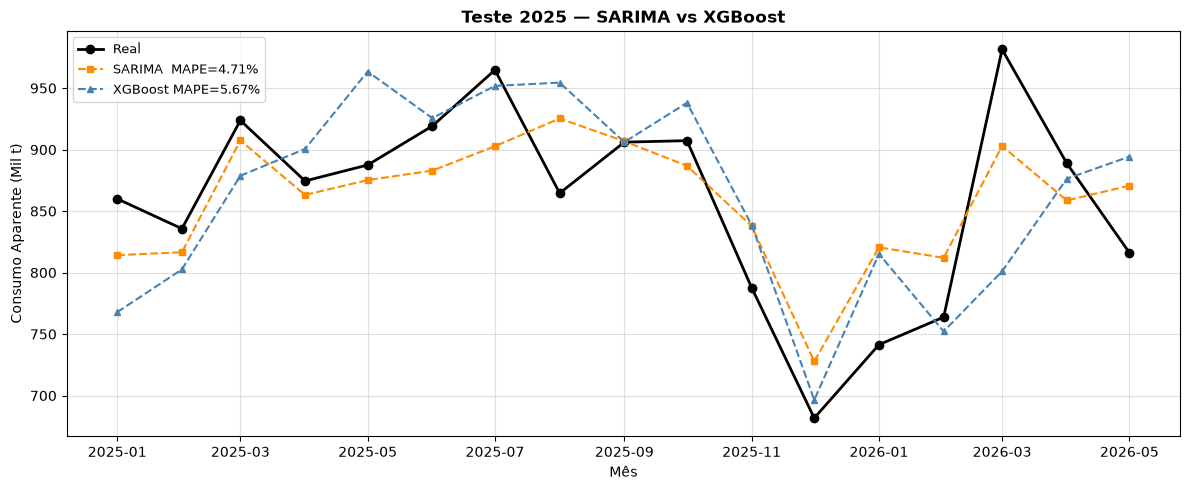

In [34]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(test_ts.index, test_ts.values,         label='Real',    color='black',   marker='o', markersize=6, linewidth=2)
ax.plot(test_ts.index, sarima_test_pred.values, label=f'SARIMA  MAPE={sarima_mape_test:.2%}',
        color='darkorange', linestyle='--', marker='s', markersize=5)
ax.plot(test_ts.index, y_pred_test_opt,         label=f'XGBoost MAPE={mape_test_opt:.2%}',
        color='steelblue',  linestyle='--', marker='^', markersize=5)

ax.set_title('Teste 2025 — SARIMA vs XGBoost', fontsize=12, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Consumo Aparente (Mil t)')
ax.legend(fontsize=9)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(f'./{path_secao_atual}/sarima_vs_xgboost_test2025.png', bbox_inches='tight')

## Previsão com Horizonte Real (Recursive Multi-Step Forecasting)

O modelo avaliado até aqui usa lags e features externas *já conhecidos* no momento da previsão — isso é **nowcasting**, não forecasting.

Para gerar um horizonte real de N meses à frente:

1. **Retreinar em todo o histórico disponível** (incluindo o período de teste).
2. **Lags do target**: atualizados recursivamente com as previsões anteriores.
3. **Features externas** (PIM, ANFAVEA, etc.): mantidas no último valor observado — proxy conservador que evita vazar informação futura desconhecida.

A incerteza cresce com o horizonte porque erros de previsão se propagam nos lags.

In [35]:
N_HORIZONS = 12  # meses à frente para prever

# Identificar os tipos de cada feature dinamicamente
_lag_map  = {}   # col -> lag int
_roll_map = {}   # col -> janela int
_ext_cols = []   # features externas (sem defasagem natural)

for col in X_train.columns:
    if col.startswith('consumo_lag_'):
        _lag_map[col] = int(col.split('_')[-1])
    elif col.startswith('consumo_ma'):
        _roll_map[col] = int(col.replace('consumo_ma', ''))
    elif col not in ('mes_sin', 'mes_cos', 'trend'):
        _ext_cols.append(col)

print(f'Lags recursivos:  {_lag_map}')
print(f'Rolling recursivos: {_roll_map}')
print(f'Features externas (fixas): {_ext_cols}')

# ── Retreinar em todo o histórico (inclui test 2025) ──────────────────────────
X_all = df_tabela_mestre[list(X_train.columns)].copy()
y_all = df_tabela_mestre[target_col].copy()
n_all = len(y_all)
pesos_all = lambda_fator ** np.arange(n_all - 1, -1, -1)

best_params_deploy = {k: v for k, v in study.best_params.items()
                      if k != 'early_stopping_rounds'}
model_full = XGBRegressor(**best_params_deploy, random_state=0)
model_full.fit(X_all, y_all, sample_weight=pesos_all)
print(f'\nRetreino: {n_all} obs  '
      f'({df_tabela_mestre["Date"].min().date()} → {df_tabela_mestre["Date"].max().date()})')

# ── Previsão recursiva ────────────────────────────────────────────────────────
serie_hist   = list(df_tabela_mestre[target_col].values)  # buffer crescente
ultima_data  = df_tabela_mestre['Date'].max()
ultima_linha = df_tabela_mestre.iloc[-1]                  # valores fixos externos
trend_base   = int(df_tabela_mestre['trend'].max()) if 'trend' in df_tabela_mestre.columns else 0

previsoes_fut = []
datas_fut     = []

for h in range(1, N_HORIZONS + 1):
    prox_data = ultima_data + pd.DateOffset(months=h)
    X_next = {}

    for col in X_train.columns:
        if col in _lag_map:
            # lag atualizado recursivamente com previsões anteriores
            X_next[col] = serie_hist[-_lag_map[col]]
        elif col in _roll_map:
            w = _roll_map[col]
            X_next[col] = float(np.mean(serie_hist[-w:]))
        elif col == 'mes_sin':
            X_next[col] = np.sin(2 * np.pi * prox_data.month / 12)
        elif col == 'mes_cos':
            X_next[col] = np.cos(2 * np.pi * prox_data.month / 12)
        elif col == 'trend':
            X_next[col] = trend_base + h
        else:
            # feature externa: último valor conhecido (assumir sem mudança)
            X_next[col] = float(ultima_linha[col])

    pred = float(model_full.predict(pd.DataFrame([X_next])[list(X_train.columns)])[0])
    serie_hist.append(pred)   # alimenta os lags da próxima etapa
    previsoes_fut.append(pred)
    datas_fut.append(prox_data)

forecast_df = pd.DataFrame({'Data': datas_fut, 'Previsao': previsoes_fut})
print(f'\nPrevisão recursiva — {N_HORIZONS} meses à frente:')
print(forecast_df.assign(Data=forecast_df['Data'].dt.strftime('%Y-%m')).to_string(index=False))


Lags recursivos:  {'consumo_lag_1': 1, 'consumo_lag_2': 2}
Rolling recursivos: {'consumo_ma3': 3}
Features externas (fixas): ['3.24 Metalurgia', 'CAMINHÕES_Produção', 'm2', 'kw', '3.30 Fabricação de outros equipamentos de transporte, exceto veículos automotores', 'Outra', 'AUTOVEÍCULOS TOTAL_Produção', 'kva', 'VALUE (R$)', 'PIB_mensal']

Retreino: 149 obs  (2014-01-01 → 2026-05-01)

Previsão recursiva — 12 meses à frente:
   Data   Previsao
2026-06 807.155334
2026-07 797.781494
2026-08 788.600586
2026-09 785.985474
2026-10 763.940796
2026-11 741.861328
2026-12 740.193481
2027-01 754.211243
2027-02 774.603210
2027-03 794.748840
2027-04 800.075317
2027-05 803.218506


Gráfico salvo.


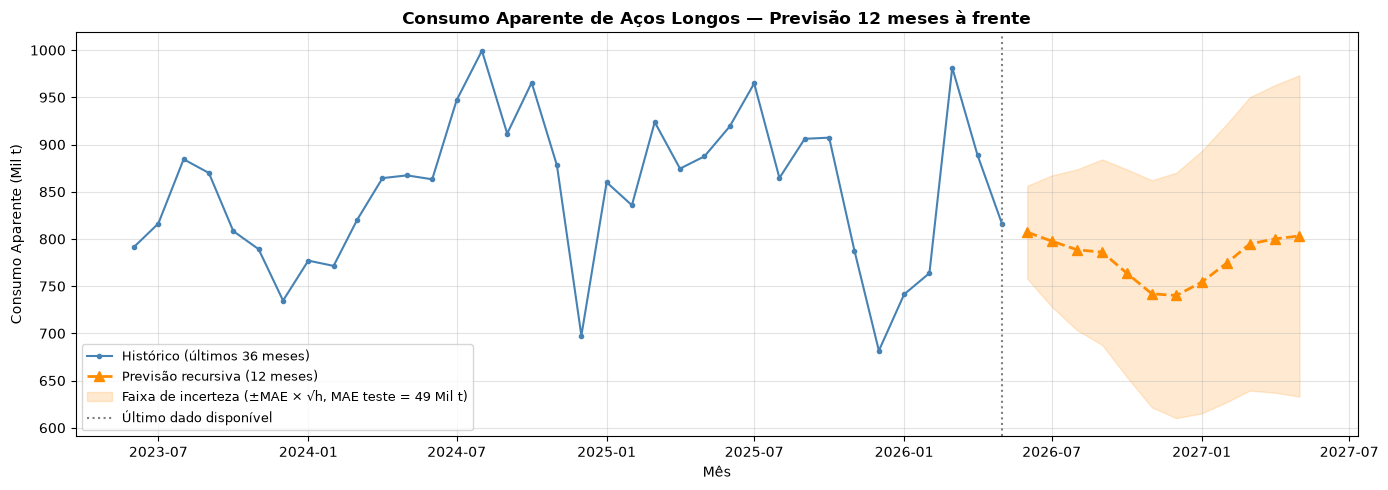

In [36]:
# Contexto histórico (últimos 36 meses) + previsão futura
hist_plot = df_tabela_mestre.set_index('Date')[target_col].sort_index()
hist_ctx  = hist_plot.iloc[-36:]

# Banda de incerteza: ±MAE do test como proxy de erro de 1 passo;
# aumenta proporcionalmente com o horizonte (erro acumula recursivamente)
mae_ref     = mae_test_opt
horizons    = np.arange(1, N_HORIZONS + 1)
error_bands = mae_ref * np.sqrt(horizons)  # ≈ erro de uma random walk

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(hist_ctx.index, hist_ctx.values,
        label='Histórico (últimos 36 meses)', color='steelblue',
        marker='o', markersize=3)

ax.plot(forecast_df['Data'], forecast_df['Previsao'],
        label=f'Previsão recursiva ({N_HORIZONS} meses)', color='darkorange',
        linestyle='--', marker='^', markersize=7, linewidth=2)

ax.fill_between(
    forecast_df['Data'],
    forecast_df['Previsao'] - error_bands,
    forecast_df['Previsao'] + error_bands,
    alpha=0.18, color='darkorange',
    label=f'Faixa de incerteza (±MAE × √h, MAE teste = {mae_ref:.0f} Mil t)',
)

ax.axvline(ultima_data, color='gray', linestyle=':', linewidth=1.5,
           label='Último dado disponível')

ax.set_title(f'Consumo Aparente de Aços Longos — Previsão {N_HORIZONS} meses à frente',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Consumo Aparente (Mil t)')
ax.legend(fontsize=9)
ax.grid(alpha=0.35)
plt.tight_layout()
plt.savefig(f'./{path_secao_atual}/forecast_futuro_{N_HORIZONS}m.png', bbox_inches='tight')
print('Gráfico salvo.')


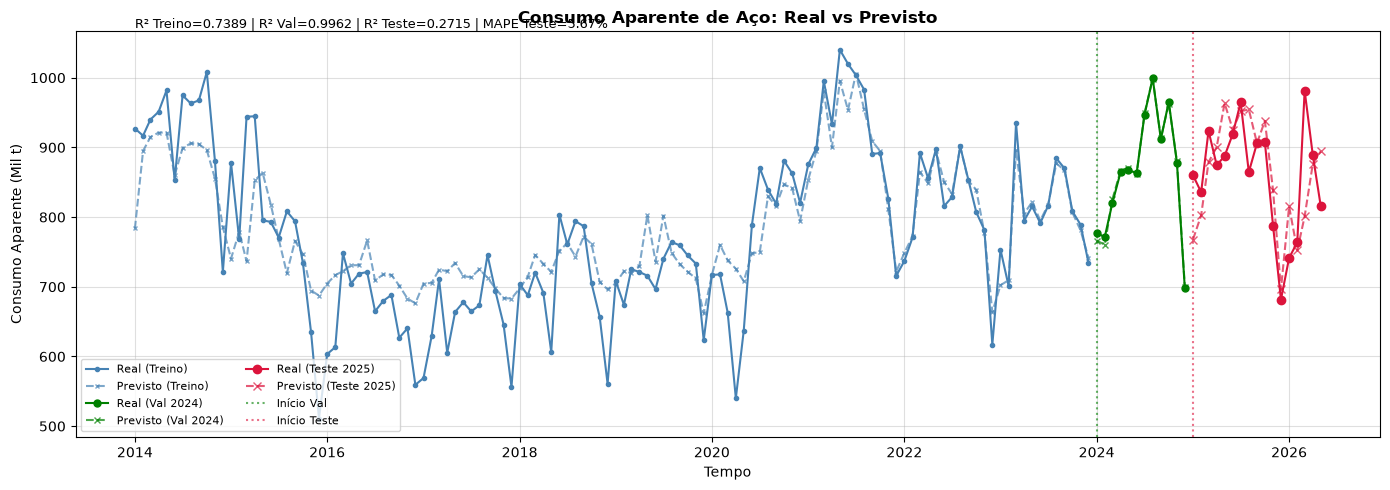

In [37]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_train['Date'], y_train.values, label='Real (Treino)', marker='o', markersize=3, color='steelblue')
ax.plot(df_train['Date'], y_pred_train_opt, label='Previsto (Treino)', linestyle='--', marker='x', markersize=3, color='steelblue', alpha=0.7)

ax.plot(df_val['Date'], y_val.values, label='Real (Val 2024)', marker='o', markersize=5, color='green')
ax.plot(df_val['Date'], y_pred_val_opt, label='Previsto (Val 2024)', linestyle='--', marker='x', markersize=5, color='green', alpha=0.7)

ax.plot(df_test['Date'], y_test.values, label='Real (Teste 2025)', marker='o', markersize=6, color='crimson')
ax.plot(df_test['Date'], y_pred_test_opt, label='Previsto (Teste 2025)', linestyle='--', marker='x', markersize=6, color='crimson', alpha=0.7)

ax.axvline(pd.Timestamp('2024-01-01'), color='green', linestyle=':', alpha=0.6, label='Início Val')
ax.axvline(pd.Timestamp('2025-01-01'), color='crimson', linestyle=':', alpha=0.6, label='Início Teste')

ax.set_title('Consumo Aparente de Aço: Real vs Previsto', fontsize=12, fontweight='bold')
ax.set_xlabel('Tempo')
ax.set_ylabel('Consumo Aparente (Mil t)')
ax.text(df_train['Date'].iloc[0], y_train.max() * 1.03,
        f'R² Treino={r2_train_opt} | R² Val={r2_val_opt} | R² Teste={r2_test_opt} | MAPE Teste={mape_test_opt:.2%}',
        fontsize=9)
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(f'./{path_secao_atual}/real_x_predito_r2_train_{r2_train_opt}_r2_test_{r2_test_opt}.png', bbox_inches='tight')

# Importância das variáveis

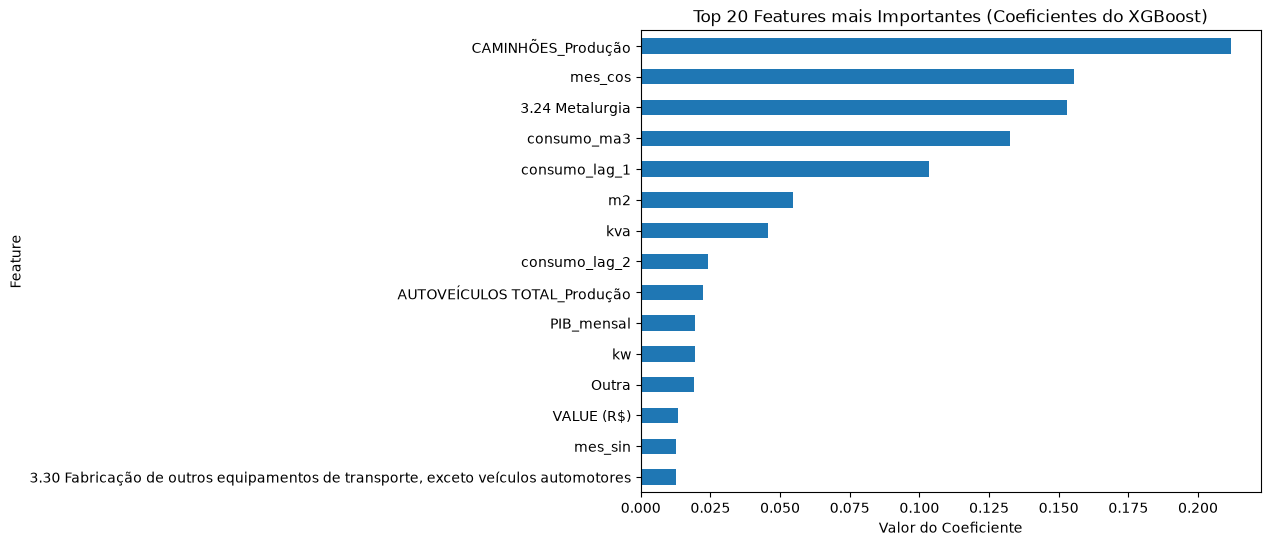

In [38]:
coefs = pd.Series(best_model.feature_importances_, index=best_model.feature_names_in_)

plt.figure(figsize=(8, 6))
coefs.sort_values(key=abs, ascending=True).tail(20).plot(kind='barh')
plt.title('Top 20 Features mais Importantes (Coeficientes do XGBoost)')
plt.xlabel('Valor do Coeficiente')
plt.ylabel('Feature')
plt.savefig(f'./{path_secao_atual}/top_20_features_r2_train_{r2_train_opt}_r2_test_{r2_test_opt}.png', bbox_inches='tight')

# Salvar modelo

In [39]:
os.makedirs('./Modelos', exist_ok=True)
best_model_name = type(best_model).__name__
pickle.dump(best_model, open(f'./{path_secao_atual}/{best_model_name}_r2_train_{r2_train_opt}_r2_test_{r2_test_opt}.pkl', 'wb'))

# Salvar dados utilizados na execução

In [40]:
df_valid_data = pd.concat([
    X_train.assign(y_real=y_train.values, y_pred=y_pred_train_opt, split='train'),
    X_val.assign(y_real=y_val.values,     y_pred=y_pred_val_opt,   split='val'),
    X_test.assign(y_real=y_test.values,   y_pred=y_pred_test_opt,  split='test'),
]).reset_index(drop=True)

df_valid_data.to_excel(
    f'./{path_secao_atual}/valid_data_{best_model_name}_r2_train_{r2_train_opt}_r2_test_{r2_test_opt}.xlsx',
    index=False, engine='openpyxl'
)

In [41]:
df_valid_data.head()

,consumo_ma3,3.24 Metalurgia,mes_cos,CAMINHÕES_Produção,m2,consumo_lag_1,kw,"3.30 Fabricação de outros equipamentos de transporte, exceto veículos automotores",mes_sin,Outra,AUTOVEÍCULOS TOTAL_Produção,kva,consumo_lag_2,VALUE (R$),PIB_mensal,y_real,y_pred,split
0,949.954333,1598.927,8.660254e-01,13776,7793517.45,769.865,0.00,1304.52774,0.500000,5.273980e+05,237390,150.0,995.462,1.690171,453274.2,927.046,783.673523,train
1,897.457667,1598.927,5.000000e-01,15174,4172578.38,927.046,60000.00,1304.52774,0.866025,1.882174e+06,281627,0.0,769.865,1.702207,455505.4,916.842,894.963745,train
2,871.251000,1598.927,6.123234e-17,13844,3919601.95,916.842,51050.17,1304.52774,1.000000,1.281491e+08,272754,500.0,927.046,1.425303,477201.5,940.044,914.856323,train
3,927.977333,1598.927,-5.000000e-01,12314,5182198.92,940.044,56000.00,1304.52774,0.866025,2.380034e+06,277091,0.0,916.842,1.488117,479725.1,951.105,921.250366,train
4,935.997000,1598.927,-8.660254e-01,12695,5714652.20,951.105,0.00,1304.52774,0.500000,2.394161e+06,281355,0.0,940.044,1.504061,481271.5,981.738,921.250366,train


In [42]:
df_valid_data.shape

(149, 18)

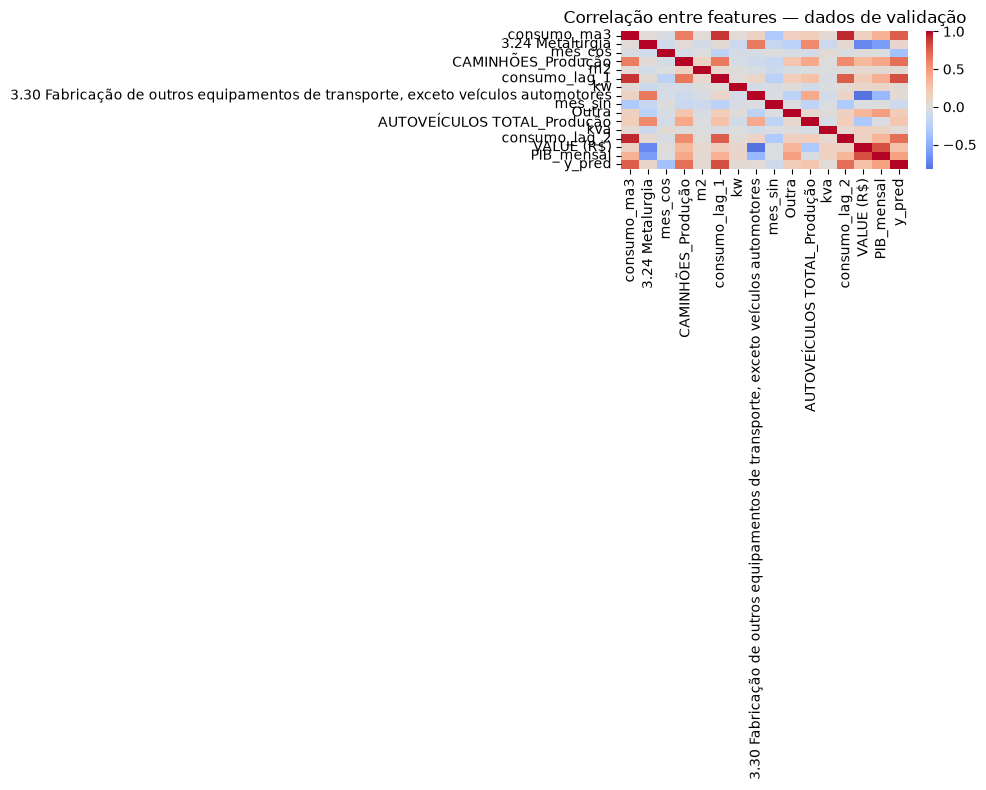

In [43]:
numeric_valid = df_valid_data.select_dtypes(include='number').drop(columns=['y_real'], errors='ignore')
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_valid.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Correlação entre features — dados de validação')
plt.tight_layout()
plt.savefig(f'./{path_secao_atual}/correlation_matrix_{r2_train_opt}_r2_test_{r2_test_opt}.png', bbox_inches='tight')

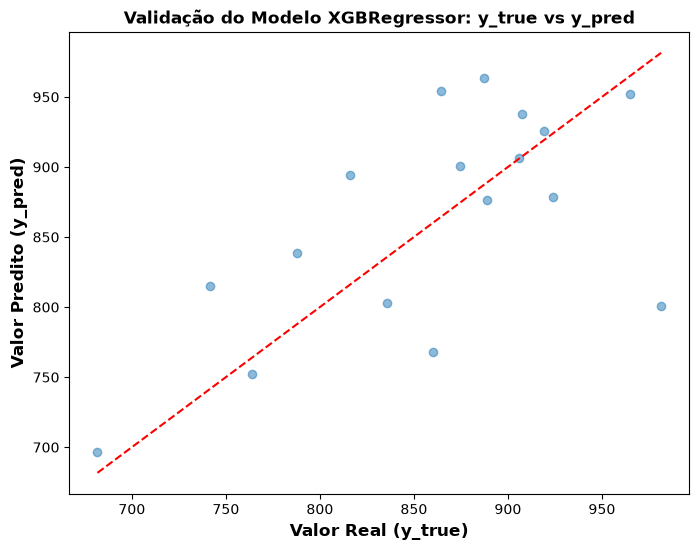

In [44]:
plt.figure(figsize=(8,6))
plt.scatter(y_test.values, y_pred_test_opt, alpha=0.5)
min_val = min(np.min(y_test.values), np.min(y_pred_test_opt))
max_val = max(np.max(y_test.values), np.max(y_pred_test_opt))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
plt.xlabel('Valor Real (y_true)', fontsize=12, fontweight='bold')
plt.ylabel('Valor Predito (y_pred)', fontsize=12, fontweight='bold')
plt.title(f'Validação do Modelo {best_model_name}: y_true vs y_pred', fontsize=12, fontweight='bold')
plt.savefig(f'./{path_secao_atual}/dispersion_y_true_x_y_pred_{r2_train_opt}_r2_test_{r2_test_opt}.png', bbox_inches='tight')